1. import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

2. Load Dataset

In [ ]:
df = pd.read_csv("../data/student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


3. Explore Dataset

In [3]:
df.shape

(395, 33)

In [4]:
df.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [5]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

4. Remove Duplicates

In [7]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

5. Average Final Grade (G3)

In [8]:
average_grade = df["G3"].mean()

print("Average final grade:", average_grade)

Average final grade: 10.415189873417722


6. Count Students Scoring Above 15

In [9]:
students_above_15 = (df["G3"] > 15).sum()

print("Students scoring above 15:", students_above_15)

Students scoring above 15: 40


7. Check Study Time vs Performance Correlation

In [10]:
correlation = df["studytime"].corr(df["G3"])

print("Correlation between study time and final grade:", correlation)

Correlation between study time and final grade: 0.09781968965319636


8. Average Performance by Gender

In [11]:
gender_performance = df.groupby("sex")["G3"].mean()

print(gender_performance)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


9. Find Which Gender Performs Better

In [12]:
better_gender = gender_performance.idxmax()
better_score = gender_performance.max()

print("Gender performing better:", better_gender)
print("Average score:", better_score)

Gender performing better: M
Average score: 10.914438502673796


10. Visualizations

10.1. Histogram of Grades

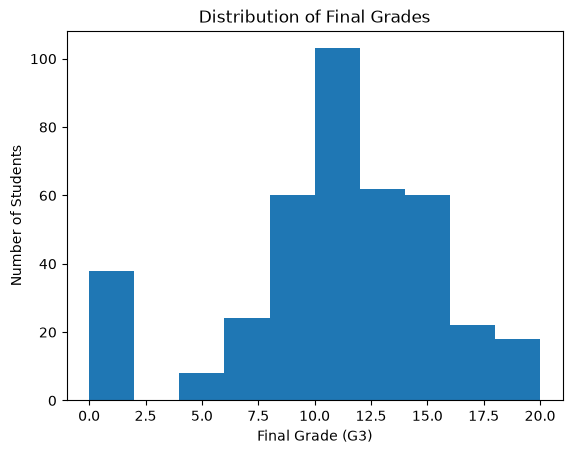

In [15]:
plt.hist(df["G3"], bins=10)

plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")

plt.show()

10.2. Scatterplot: Study Time vs Grades

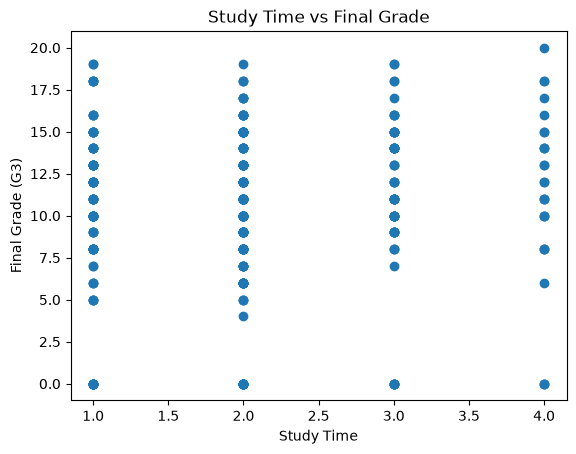

In [16]:
plt.scatter(df["studytime"], df["G3"])

plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.title("Study Time vs Final Grade")

plt.show()

10.3. Bar Chart: Male vs Female Average Score

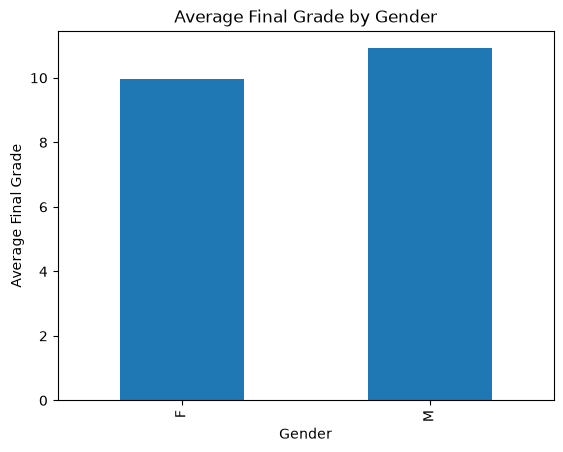

In [17]:
gender_performance.plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Gender")

plt.show()

11. Display Final Results Together

In [18]:
print("Average final grade:", df["G3"].mean())
print("Students scoring above 15:", (df["G3"] > 15).sum())
print("Study time vs grade correlation:", df["studytime"].corr(df["G3"]))

print("\nAverage grade by gender:")
print(df.groupby("sex")["G3"].mean())

Average final grade: 10.415189873417722
Students scoring above 15: 40
Study time vs grade correlation: 0.09781968965319636

Average grade by gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64
